# Mixture Models

Mixture Models are probabilistic models that assume the observed data is generated from a combination, or mixture, of several underlying probability distributions.

Instead of assuming that all observations come from a single distribution, a Mixture Model assumes that different observations may come from different hidden groups.

A common example is the Gaussian Mixture Model (GMM), where each hidden group is represented by a Gaussian distribution.

Mixture Models are widely used for:

- Clustering
- Density estimation
- Anomaly detection
- Image segmentation
- Customer segmentation
- Speech recognition
- Pattern recognition
- Discovering hidden subpopulations

## What is a Mixture Model?

A Mixture Model represents a probability distribution as a weighted combination of several component distributions.

Suppose we have K component distributions.

The overall probability density is:

$$
p(x) = \sum_{k=1}^{K} \pi_k p(x \mid z=k)
$$

where:

- K = number of mixture components
- π_k = mixing weight of component k
- p(x | z=k) = probability distribution of component k
- z = hidden or latent component assignment

The mixing weights satisfy:

$$
\pi_k \geq 0
$$

and

$$
\sum_{k=1}^{K} \pi_k = 1
$$

Therefore, a Mixture Model can be viewed as a weighted combination of multiple probability distributions.

## Intuition Behind Mixture Models

Imagine a dataset containing the heights of people.

The entire population may contain several underlying groups:

- Children
- Teenagers
- Adults

Instead of modeling all heights using one Gaussian distribution, we could model the population using several Gaussian distributions.

For example:

$$
p(x)
=
\pi_1 \mathcal{N}(x \mid \mu_1,\Sigma_1)
+
\pi_2 \mathcal{N}(x \mid \mu_2,\Sigma_2)
+
\pi_3 \mathcal{N}(x \mid \mu_3,\Sigma_3)
$$

Each Gaussian represents one hidden population.

The important idea is that the group labels are not directly observed.

The model tries to discover:

- Which components exist
- Where each component is located
- How spread out each component is
- How important each component is
- How likely each observation belongs to each component

## Generative Process

A Mixture Model can be understood as a generative process.

For each observation:

1. Choose a mixture component according to its mixing probability.
2. Generate the observation from the selected component distribution.

First choose a latent component:

$$
z \sim \text{Categorical}(\pi_1,\pi_2,\ldots,\pi_K)
$$

Then generate the observation:

$$
x \sim p(x \mid z)
$$

For a Gaussian Mixture Model:

$$
x \mid z=k \sim \mathcal{N}(\mu_k,\Sigma_k)
$$

The component assignment z is hidden.

Therefore, z is called a latent variable.

## Latent Variables

A latent variable is a variable that is not directly observed but is used to explain the observed data.

In a Mixture Model:

- x = observed data
- z = hidden component assignment

For example, suppose we observe:

$$
x_1,x_2,\ldots,x_n
$$

but do not know which component generated each observation.

The hidden assignments are:

$$
z_1,z_2,\ldots,z_n
$$

The model attempts to infer these hidden assignments from the observed data.

# Gaussian Mixture Model

A Gaussian Mixture Model (GMM) assumes that the data is generated from a mixture of Gaussian distributions.

For K Gaussian components:

$$
p(x)
=
\sum_{k=1}^{K}
\pi_k
\mathcal{N}(x \mid \mu_k,\Sigma_k)
$$

where:

- π_k = mixing weight
- μ_k = mean vector
- Σ_k = covariance matrix
- K = number of Gaussian components

The mixing weights satisfy:

$$
\sum_{k=1}^{K}\pi_k = 1
$$

Each Gaussian component represents a possible underlying group in the data.

## Gaussian Distribution

For a d-dimensional observation x, the multivariate Gaussian distribution is:

$$
\mathcal{N}(x \mid \mu,\Sigma)
=
\frac{1}
{(2\pi)^{d/2}|\Sigma|^{1/2}}
\exp
\left(
-\frac{1}{2}
(x-\mu)^T
\Sigma^{-1}
(x-\mu)
\right)
$$

where:

- μ = mean vector
- Σ = covariance matrix
- |Σ| = determinant of the covariance matrix
- Σ⁻¹ = inverse covariance matrix
- d = number of features

The mean controls the center of the distribution.

The covariance controls the shape, orientation, and spread of the distribution.

## Parameters of a Gaussian Mixture Model

For K Gaussian components, the model learns three types of parameters.

### 1. Mixing weights

$$
\pi_1,\pi_2,\ldots,\pi_K
$$

They determine how much each component contributes to the overall distribution.

### 2. Mean vectors

$$
\mu_1,\mu_2,\ldots,\mu_K
$$

They determine the center of each Gaussian component.

### 3. Covariance matrices

$$
\Sigma_1,\Sigma_2,\ldots,\Sigma_K
$$

They determine the spread and orientation of each component.

Therefore, GMM learns:

$$
\Theta =
\{\pi_k,\mu_k,\Sigma_k\}_{k=1}^{K}
$$

## GMM vs K-Means

Both K-Means and GMM can be used for clustering, but they make different assumptions.

### K-Means

K-Means assigns every observation to exactly one cluster.

The result is a hard assignment.

For example:

$$
z_i \in \{1,2,\ldots,K\}
$$

### GMM

GMM provides a probability for every component.

For example:

$$
P(z_i=1\mid x_i)=0.80
$$

$$
P(z_i=2\mid x_i)=0.15
$$

$$
P(z_i=3\mid x_i)=0.05
$$

Therefore, GMM provides soft clustering.

GMM also models the shape and covariance of each cluster, whereas K-Means primarily uses distances to cluster centers.

## Why Use Gaussian Mixture Models?

GMM is useful when clusters are not well represented by simple spherical regions.

For example:

- Circular clusters
- Elliptical clusters
- Rotated clusters
- Clusters with different spreads
- Overlapping clusters

K-Means assumes that clusters are roughly spherical around their centroids.

GMM is more flexible because each component has its own covariance matrix.

Therefore, GMM can model:

- Different cluster sizes
- Different orientations
- Different variances
- Overlapping distributions

# Likelihood in Mixture Models

The probability of an observation under a GMM is:

$$
p(x_i)
=
\sum_{k=1}^{K}
\pi_k
\mathcal{N}(x_i\mid\mu_k,\Sigma_k)
$$

For n independent observations:

$$
p(X)
=
\prod_{i=1}^{n}
\sum_{k=1}^{K}
\pi_k
\mathcal{N}(x_i\mid\mu_k,\Sigma_k)
$$

The goal is to find model parameters that maximize the likelihood of observing the data.

Therefore:

$$
\Theta^*
=
\arg\max_{\Theta} p(X\mid\Theta)
$$

In practice, we usually maximize the log-likelihood.

## Log-Likelihood

The log-likelihood is:

$$
\log p(X\mid\Theta)
=
\sum_{i=1}^{n}
\log
\left[
\sum_{k=1}^{K}
\pi_k
\mathcal{N}(x_i\mid\mu_k,\Sigma_k)
\right]
$$

The logarithm converts the product into a sum, making optimization more convenient.

However, the expression contains a logarithm of a sum:

$$
\log
\left(
\sum_k \pi_k
\mathcal{N}(x_i\mid\mu_k,\Sigma_k)
\right)
$$

This makes direct optimization difficult.

The Expectation-Maximization algorithm is commonly used to estimate the parameters of a GMM.

# Expectation-Maximization Algorithm

Expectation-Maximization (EM) is an iterative optimization algorithm commonly used to estimate parameters when latent variables are involved.

For GMM, EM alternates between two steps:

1. Expectation step (E-step)
2. Maximization step (M-step)

The process is:

$$
\text{Initialize parameters}
\rightarrow
E\text{-step}
\rightarrow
M\text{-step}
\rightarrow
E\text{-step}
\rightarrow
M\text{-step}
\rightarrow \cdots
$$

The algorithm continues until convergence.

## E-Step: Estimate Responsibilities

In the E-step, we calculate the probability that observation x_i belongs to component k.

This probability is called the responsibility.

It is given by:

$$
\gamma_{ik}
=
P(z_i=k\mid x_i)
$$

Using Bayes' theorem:

$$
\gamma_{ik}
=
\frac{
\pi_k
\mathcal{N}(x_i\mid\mu_k,\Sigma_k)
}{
\sum_{j=1}^{K}
\pi_j
\mathcal{N}(x_i\mid\mu_j,\Sigma_j)
}
$$

The responsibilities satisfy:

$$
\sum_{k=1}^{K}\gamma_{ik}=1
$$

Therefore, each observation receives a probability distribution over the mixture components.

## M-Step: Update Parameters

In the M-step, the model updates the mixture parameters using the responsibilities calculated during the E-step.

First calculate the effective number of observations assigned to component k:

$$
N_k
=
\sum_{i=1}^{n}\gamma_{ik}
$$

### Update mixing weight

$$
\pi_k
=
\frac{N_k}{n}
$$

### Update mean

$$
\mu_k
=
\frac{1}{N_k}
\sum_{i=1}^{n}
\gamma_{ik}x_i
$$

### Update covariance

$$
\Sigma_k
=
\frac{1}{N_k}
\sum_{i=1}^{n}
\gamma_{ik}
(x_i-\mu_k)(x_i-\mu_k)^T
$$

After updating the parameters, the algorithm returns to the E-step.

## EM Algorithm Summary

The complete EM procedure for GMM is:

### Step 1 — Initialize

Initialize:

$$
\pi_k,\mu_k,\Sigma_k
$$

### Step 2 — E-Step

Calculate responsibilities:

$$
\gamma_{ik}
=
P(z_i=k\mid x_i)
$$

### Step 3 — M-Step

Update:

$$
\pi_k,\mu_k,\Sigma_k
$$

### Step 4 — Evaluate

Calculate the log-likelihood.

### Step 5 — Repeat

Continue E-step and M-step until the model converges.

The objective is to increase the likelihood of the observed data until convergence to a local optimum.

## Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score

## Creating a Dataset

We will create a synthetic dataset containing several groups.

The purpose is to understand how GMM discovers the underlying probability distributions.

In [2]:
X, y_true = make_blobs(
    n_samples=500,
    centers=3,
    cluster_std=[1.0, 2.0, 0.8],
    random_state=42
)

X.shape

(500, 2)

## Visualize Dataset

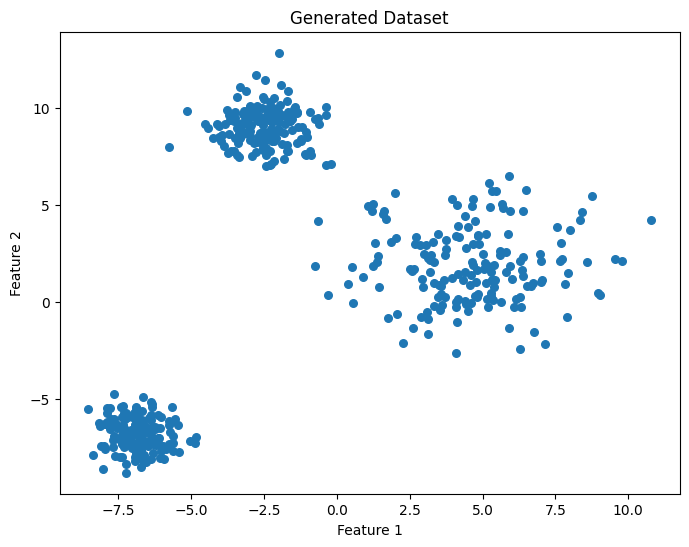

In [3]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    s=30
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated Dataset")

plt.show()

# Training a Gaussian Mixture Model

We will now fit a Gaussian Mixture Model to the dataset.

We need to specify the number of mixture components.

Here we will initially assume that there are 3 components.

In [4]:
gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

gmm.fit(X)

,"n_components n_components: int, default=1The number of mixture components.",3
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


## Learned Means

In [5]:
gmm.means_

array([[ 4.58592542,  1.8932066 ],
       [-6.84088545, -6.78128227],
       [-2.51448707,  9.03589347]])

The learned means represent the centers of the Gaussian components.

Each component has its own mean vector.

## Mixing Weights

In [6]:
gmm.weights_

array([0.33417115, 0.332     , 0.33382886])

The mixing weights indicate the relative contribution of each Gaussian component.

The weights satisfy:

$$
\sum_{k=1}^{K}\pi_k=1
$$

## Covariance Matrices

In [7]:
gmm.covariances_

array([[[ 4.52946509,  0.08246609],
        [ 0.08246609,  3.75646372]],

       [[ 0.49610205, -0.05764791],
        [-0.05764791,  0.66355257]],

       [[ 0.8992755 , -0.0110908 ],
        [-0.0110908 ,  0.95282686]]])

Each component also has its own covariance matrix.

The covariance determines the shape and orientation of the Gaussian component.

## Hard Cluster Assignment

Although GMM produces probabilities, we can obtain a hard cluster assignment by selecting the component with the highest probability.

The predicted cluster is:

$$
\hat{z}_i
=
\arg\max_k P(z_i=k\mid x_i)
$$

In [8]:
labels = gmm.predict(X)

labels[:20]

array([1, 0, 0, 2, 0, 0, 1, 0, 0, 1, 0, 2, 2, 2, 0, 0, 2, 1, 1, 2])

## Visualize GMM Clusters

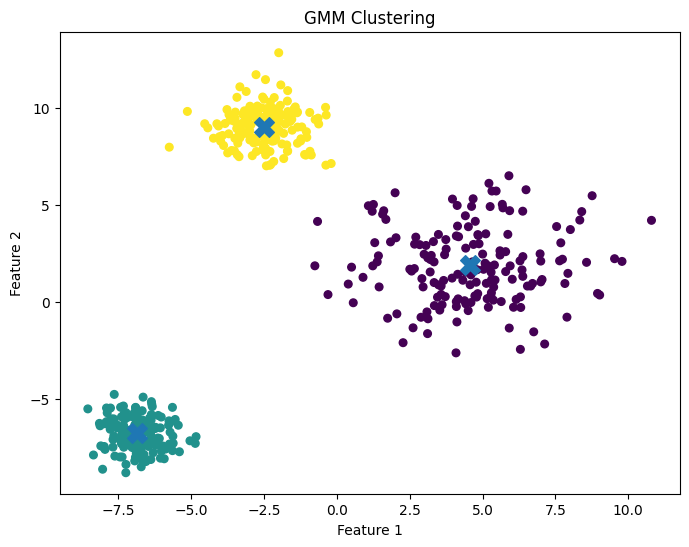

In [9]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    s=30
)

plt.scatter(
    gmm.means_[:, 0],
    gmm.means_[:, 1],
    marker="X",
    s=200
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("GMM Clustering")

plt.show()

# Soft Clustering

One of the biggest advantages of GMM is that it provides probabilities instead of only cluster labels.

For every observation, GMM calculates:

$$
P(z_i=1\mid x_i),
P(z_i=2\mid x_i),
\ldots,
P(z_i=K\mid x_i)
$$

These probabilities are called responsibilities.

An observation may therefore belong partially to multiple components.

In [10]:
probabilities = gmm.predict_proba(X)

probabilities[:5]

array([[2.62820352e-011, 1.00000000e+000, 1.43167667e-065],
       [1.00000000e+000, 1.21659968e-043, 4.13188323e-011],
       [1.00000000e+000, 1.51396519e-135, 1.01600796e-047],
       [1.84006040e-005, 4.40455358e-079, 9.99981599e-001],
       [1.00000000e+000, 4.52300256e-114, 1.54900650e-035]])

## Check Responsibilities

In [11]:
probabilities[0]

array([2.62820352e-11, 1.00000000e+00, 1.43167667e-65])

In [12]:
probabilities[0].sum()

np.float64(1.0)

For every observation, the responsibilities sum to 1:

$$
\sum_{k=1}^{K}\gamma_{ik}=1
$$

This means the responsibilities form a probability distribution over the components.

## Finding Ambiguous Observations

GMM can identify observations that are difficult to assign to a single component.

If the highest probability is close to 1, the assignment is confident.

If probabilities are similar across components, the observation lies near overlapping regions.

This is useful when clusters naturally overlap.

In [13]:
max_probabilities = probabilities.max(axis=1)

uncertain_indices = np.argsort(max_probabilities)[:10]

probabilities[uncertain_indices]

array([[4.71835644e-02, 3.14159891e-89, 9.52816436e-01],
       [3.35081560e-02, 2.82850279e-87, 9.66491844e-01],
       [1.24789640e-03, 6.15546558e-90, 9.98752104e-01],
       [7.22733060e-04, 8.16976236e-89, 9.99277267e-01],
       [6.13190341e-04, 1.01197469e-91, 9.99386810e-01],
       [5.84148901e-04, 5.80709175e-89, 9.99415851e-01],
       [2.31811440e-04, 7.64214575e-77, 9.99768189e-01],
       [2.09316486e-04, 1.71887426e-77, 9.99790684e-01],
       [2.09289910e-04, 5.67754542e-76, 9.99790710e-01],
       [1.86428312e-04, 6.68505240e-83, 9.99813572e-01]])

# Choosing the Number of Components

The number of mixture components K is an important hyperparameter.

If K is too small:

- Important structure may be missed.
- Different groups may be merged.

If K is too large:

- The model may overfit.
- One real group may be represented by multiple components.
- The model becomes unnecessarily complex.

Common approaches include:

- AIC
- BIC
- Cross-validation
- Domain knowledge
- Visual inspection

## Akaike Information Criterion

AIC balances model fit and model complexity.

The general form is:

$$
AIC
=
2p
-
2\log L
$$

where:

- p = number of estimated parameters
- L = maximum likelihood

A lower AIC is generally preferred.

AIC tends to be more tolerant of model complexity than BIC.

## Bayesian Information Criterion

BIC also balances model fit and model complexity.

The general form is:

$$
BIC
=
p\log(n)
-
2\log L
$$

where:

- p = number of parameters
- n = number of observations
- L = maximum likelihood

A lower BIC is preferred.

BIC applies a stronger penalty for model complexity than AIC.

## AIC and BIC in Python

In [14]:
components = range(1, 8)

aic_scores = []
bic_scores = []

for k in components:
    model = GaussianMixture(
        n_components=k,
        random_state=42
    )

    model.fit(X)

    aic_scores.append(model.aic(X))
    bic_scores.append(model.bic(X))

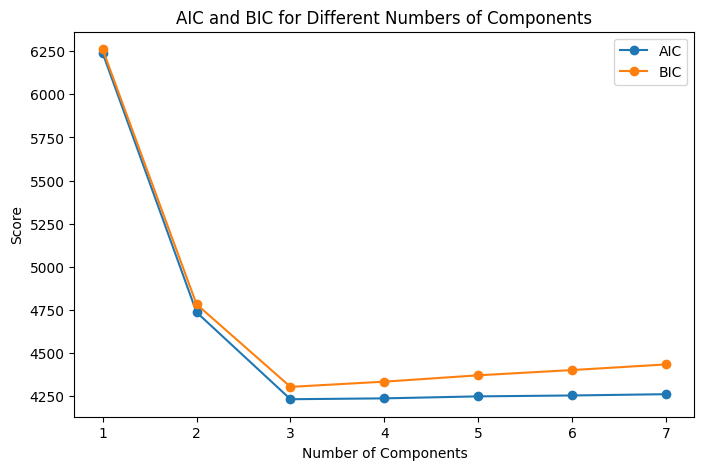

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    components,
    aic_scores,
    marker="o",
    label="AIC"
)

plt.plot(
    components,
    bic_scores,
    marker="o",
    label="BIC"
)

plt.xlabel("Number of Components")
plt.ylabel("Score")
plt.title("AIC and BIC for Different Numbers of Components")

plt.legend()
plt.show()

## Best Number of Components

In [16]:
best_aic_components = components[np.argmin(aic_scores)]
best_bic_components = components[np.argmin(bic_scores)]

print("Best components according to AIC:", best_aic_components)
print("Best components according to BIC:", best_bic_components)

Best components according to AIC: 3
Best components according to BIC: 3


# Covariance Types in GMM

Scikit-learn provides different covariance structures.

### 1. Full

Each component has its own general covariance matrix.

This is the most flexible option.

### 2. Tied

All components share the same covariance matrix.

### 3. Diagonal

Each component has a diagonal covariance matrix.

Feature correlations are not modeled.

### 4. Spherical

Each component has a single variance value.

This produces spherical clusters.

The covariance type affects the shape of the clusters that the model can represent.

## Compare Covariance Types

In [17]:
covariance_types = [
    "full",
    "tied",
    "diag",
    "spherical"
]

for covariance_type in covariance_types:
    model = GaussianMixture(
        n_components=3,
        covariance_type=covariance_type,
        random_state=42
    )

    model.fit(X)

    print(
        covariance_type,
        "BIC:",
        model.bic(X)
    )

full BIC: 4302.889684085605
tied BIC: 4632.747363493273
diag BIC: 4286.017926339523
spherical BIC: 4272.469235857215


# GMM as a Generative Model

A GMM can also generate new observations.

After learning the mixture components, we can sample new points from the learned probability distribution.

This is an important difference between GMM and algorithms that only perform clustering.

The model has learned an approximation of the underlying data distribution.

In [18]:
X_generated, generated_labels = gmm.sample(300)

X_generated.shape

(300, 2)

## Visualize Generated Samples

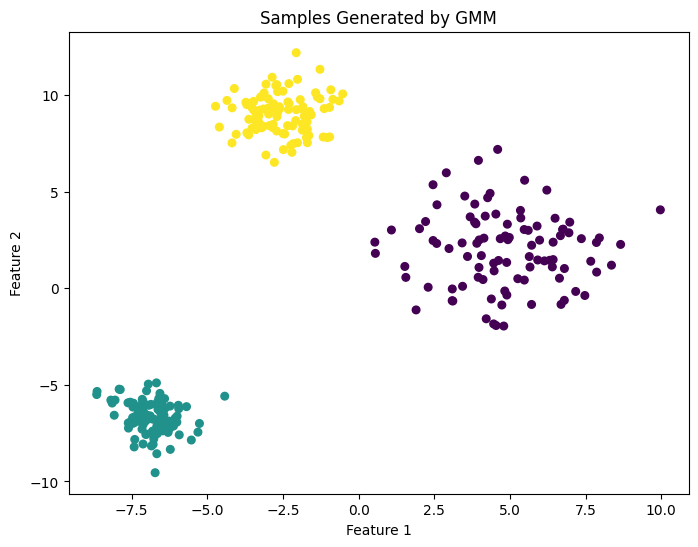

In [19]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_generated[:, 0],
    X_generated[:, 1],
    c=generated_labels,
    s=30
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Samples Generated by GMM")

plt.show()

# Density Estimation

GMM can estimate the probability density of observations.

The `score_samples()` method returns the log probability density of each observation.

Mathematically:

$$
\log p(x_i)
$$

A higher value means the observation is more likely under the learned model.

A very low value may indicate that the observation is unusual.

In [20]:
log_density = gmm.score_samples(X)

log_density[:10]

array([-3.39943884, -7.49902319, -6.86897891, -4.10587066, -5.09808402,
       -5.04379719, -6.45152067, -4.3900137 , -4.8327048 , -2.68726419])

# GMM for Anomaly Detection

Because GMM estimates probability density, it can also be used for anomaly detection.

The basic idea is:

- High probability → likely normal observation
- Low probability → potentially anomalous observation

We can define a threshold on the log-likelihood.

Observations below the threshold can be treated as potential anomalies.

However, the threshold should be selected carefully using validation data or domain knowledge.

# Complete GMM Example

We will now build a complete workflow:

1. Generate data
2. Fit GMM
3. Predict cluster labels
4. Calculate probabilities
5. Evaluate clustering
6. Visualize the result

In [21]:
X, y_true = make_blobs(
    n_samples=600,
    centers=3,
    cluster_std=[1.0, 1.8, 0.7],
    random_state=42
)

model = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42
)

model.fit(X)

labels = model.predict(X)

probabilities = model.predict_proba(X)

silhouette = silhouette_score(X, labels)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.805675076950604


## Final Visualization

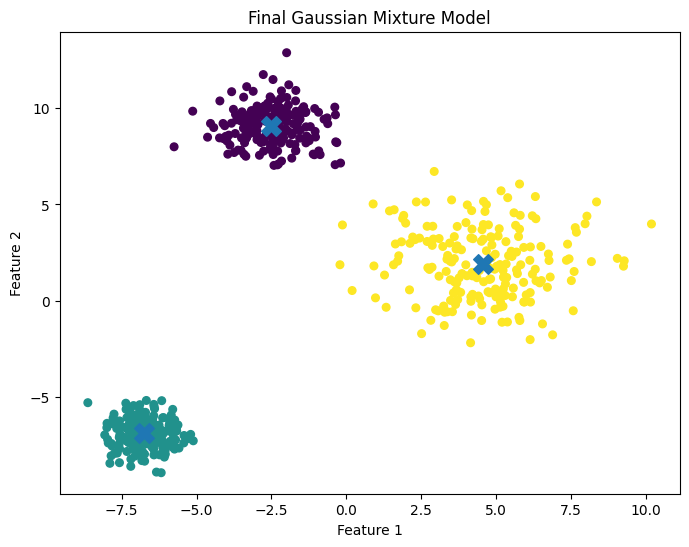

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    s=30
)

plt.scatter(
    model.means_[:, 0],
    model.means_[:, 1],
    marker="X",
    s=200
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Final Gaussian Mixture Model")

plt.show()

# Advantages of Gaussian Mixture Models

### 1. Soft clustering

GMM provides probabilities instead of only hard cluster assignments.

### 2. Flexible cluster shapes

GMM can model elliptical and rotated clusters.

### 3. Different cluster sizes

Different components can have different covariance matrices.

### 4. Density estimation

GMM models the probability density of the data.

### 5. Generative capability

The learned model can generate new observations.

### 6. Probabilistic interpretation

The model provides a principled probabilistic interpretation of cluster membership.

### 7. Useful for overlapping clusters

GMM handles situations where cluster boundaries are not clearly separated.

# Disadvantages of Gaussian Mixture Models

### 1. Number of components must usually be selected

The value of K is an important modeling decision.

### 2. Sensitive to initialization

Different initializations may produce different solutions.

### 3. Local optima

EM does not necessarily find the global optimum.

### 4. Computationally more expensive than K-Means

GMM estimates covariance matrices in addition to cluster centers.

### 5. Gaussian assumption

GMM assumes that each component can be reasonably modeled by a Gaussian distribution.

### 6. Covariance estimation can become unstable

This can happen when there are too few observations relative to the number of features.

### 7. Sensitive to outliers

Extreme observations can influence the estimated Gaussian components.

# GMM vs K-Means

| Property | K-Means | GMM |
|---|---|---|
| Type | Distance-based | Probabilistic |
| Assignment | Hard | Soft |
| Output | Cluster label | Probabilities |
| Cluster shape | Mostly spherical | Elliptical and flexible |
| Covariance | Not modeled | Explicitly modeled |
| Density estimation | No | Yes |
| Generative model | No | Yes |
| Optimization | Centroid updates | EM algorithm |
| Complexity | Lower | Higher |
| Overlapping clusters | Less suitable | More suitable |
| Probabilistic interpretation | Limited | Strong |

K-Means is often simpler and faster.

GMM is more flexible when the underlying clusters have different shapes, orientations, or spreads.

# When Should You Use GMM?

GMM is a good choice when:

- You want probabilistic cluster assignments.
- Clusters overlap.
- Clusters have elliptical shapes.
- Different clusters have different variances.
- You want density estimation.
- You want to generate new samples.
- You want a probabilistic model of the data.

Consider alternatives when:

- The data is highly non-Gaussian.
- The number of dimensions is very large.
- Clusters have complex nonlinear shapes.
- There are many extreme outliers.

# Applications of Mixture Models

Mixture Models are used in many areas.

### Customer Segmentation

Model customers as different underlying behavioral groups.

### Image Segmentation

Represent different regions of an image using different distributions.

### Anomaly Detection

Identify observations with unusually low probability.

### Speech Recognition

Model different acoustic patterns.

### Finance

Model returns as mixtures of different market regimes.

### Medical Data Analysis

Discover hidden subpopulations.

### Density Estimation

Approximate complex probability distributions using multiple simpler distributions.

### Pattern Recognition

Represent heterogeneous datasets using multiple probability components.

# Important Concepts to Remember

### Mixture Model

A probability distribution formed by combining multiple component distributions.

### Component

One probability distribution within the mixture.

### Mixing Weight

The contribution of a component to the overall distribution.

### Latent Variable

The hidden variable representing the component that generated an observation.

### Responsibility

The probability that a particular component generated an observation.

### GMM

A Mixture Model in which the component distributions are Gaussian.

### EM

An iterative algorithm used to estimate GMM parameters.

### E-Step

Estimate responsibilities.

### M-Step

Update model parameters using responsibilities.

### AIC/BIC

Model-selection criteria used to balance model fit and complexity.

# Mathematical Summary

A Gaussian Mixture Model is:

$$
p(x)
=
\sum_{k=1}^{K}
\pi_k
\mathcal{N}(x\mid\mu_k,\Sigma_k)
$$

The responsibility is:

$$
\gamma_{ik}
=
\frac{
\pi_k
\mathcal{N}(x_i\mid\mu_k,\Sigma_k)
}{
\sum_{j=1}^{K}
\pi_j
\mathcal{N}(x_i\mid\mu_j,\Sigma_j)
}
$$

The effective number of observations is:

$$
N_k
=
\sum_{i=1}^{n}\gamma_{ik}
$$

Mean update:

$$
\mu_k
=
\frac{1}{N_k}
\sum_{i=1}^{n}
\gamma_{ik}x_i
$$

Mixing weight update:

$$
\pi_k
=
\frac{N_k}{n}
$$

Covariance update:

$$
\Sigma_k
=
\frac{1}{N_k}
\sum_{i=1}^{n}
\gamma_{ik}
(x_i-\mu_k)(x_i-\mu_k)^T
$$

EM repeatedly performs:

$$
E\text{-step}
\rightarrow
M\text{-step}
\rightarrow
E\text{-step}
\rightarrow
M\text{-step}
\rightarrow \cdots
$$

# Final Takeaways

1. Mixture Models represent data using multiple probability distributions.

2. Gaussian Mixture Models use Gaussian distributions as their components.

3. GMM introduces a hidden component variable for every observation.

4. GMM performs soft clustering.

5. Each observation receives a probability of belonging to every component.

6. The EM algorithm is commonly used to estimate GMM parameters.

7. The E-step estimates responsibilities.

8. The M-step updates the mixture parameters.

9. Covariance matrices allow GMM to model different cluster shapes and orientations.

10. AIC and BIC can help select the number of components.

11. GMM can perform clustering, density estimation, anomaly detection, and data generation.

12. GMM is more flexible than K-Means but is also more computationally expensive and relies on Gaussian assumptions.